# Evaluating spectral separability

This notebook can be used to evaluate spectral separability of point-spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## Set-up 
Importing modules and data

In [1]:
# Import required scripts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import speca.label_data as sld
import speca.plot_data as spd
import speca.resampling as srs
import speca.preprocessing as prep
import speca.visualizing as sv
import pvclust
import speca.auxiliary as aux

In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

## Preprocessing

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes 
If a scaler is chosen, it will scale the data accordingly.

In [91]:
# Define preprocessing parameters
path = r"C:\Users\s4770224\Documents\coding\Spectral_analysis\Combined_analysis\MEL_NZ_TAS_spectra.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "standard"
target_scheme = "all_macros"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [102]:
#Run the preprocessing chain
prepper = prep.PreprocessRefl(data_path = path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra_norm
labels_prepped = prepper.labels_filtered

Data filtered from 388 to 333 spectra.


## Visualise the prepared reflectance spectra 

Initialize the plotting class using the already defined parameters from preprocessing.

In [171]:
# Initialize visualizer with existing parameters
vizer = sv.Visualizer(spectra_prepped, 
                      labels_prepped, 
                      start_nm, 
                      end_nm)

# Calculate class statistics for plotting
vizer.class_stats(grouping="Class", 
                  plot_by_site = True)

### Chose spectra to plot

Search words below defines what target types you want to plot. Search sites is optional, but will let you chose to plot spectra from only the specified site(s). The mode parameter can be `any` or `all` to indicate if all of the search terms need to be met or if all must be found to be returned.

In [172]:
search_words = ['acrocarpia', 'carpophyllum', 'cystophora', 'durvillaea', 'ecklonia','filamentous_rhodophyte', 'frondose_rhodophyte', 'hormosira',
       'macrocystis', 'phyllospora', 'sargassum', 'scytosiphon', 'ulva', 'petalonia', 'undaria']
search_sites = []
mode = any

In [ ]:
# Run the plotter
vizer.plot_search_terms(search_words= search_words, mode = any, search_sites = search_sites)

## Hierarchical Cluster Analysis

In [97]:
# Calculate class means for clustering
class_means = aux.calc_class_averages(spectra_prepped,
                                      labels_prepped,
                                      label_col="Class")

In [100]:
# Chose data to cluster
clust_data = class_means

# Perform clustering
pv = pvclust.PvClust(clust_data.T, method = "ward", metric = "euclidean", nboot = 10000, parallel = True)

Calculating using 16 cores... Done.


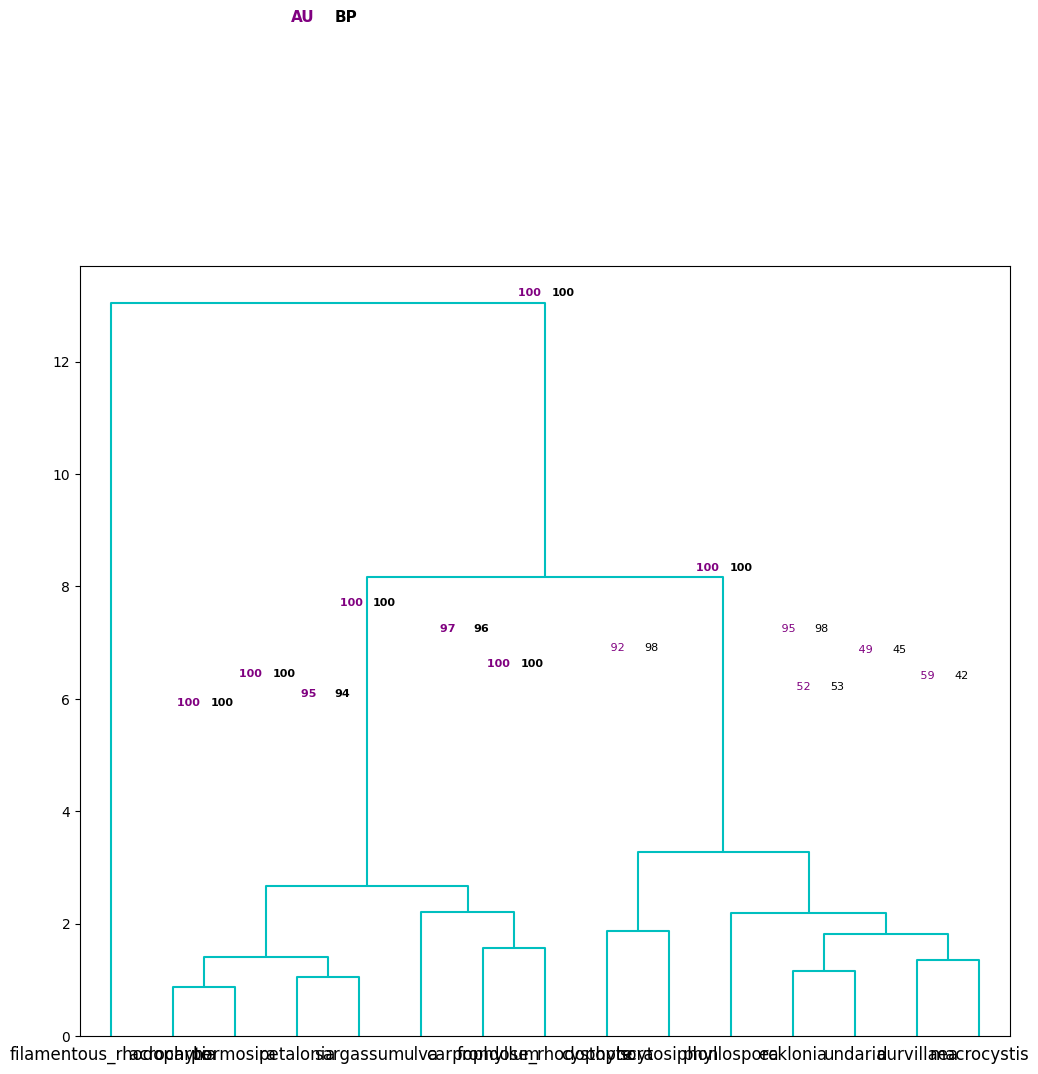

In [101]:
# Plot dendrogram
pv.plot(labels= clust_data.index.to_list())

# Testing